In [41]:
import imageio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.ndimage as ndi
import numpy as np
import pandas as pd

from module.preprocessing import *

from skimage import exposure, filters, morphology, measure

/tmp/ipykernel_165524/2728585016.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  im = imageio.imread('../dataset/Assigment1/chest_xray/val/NORMAL/NORMAL2-IM-1436-0001.jpeg')


(928, 1288) uint8


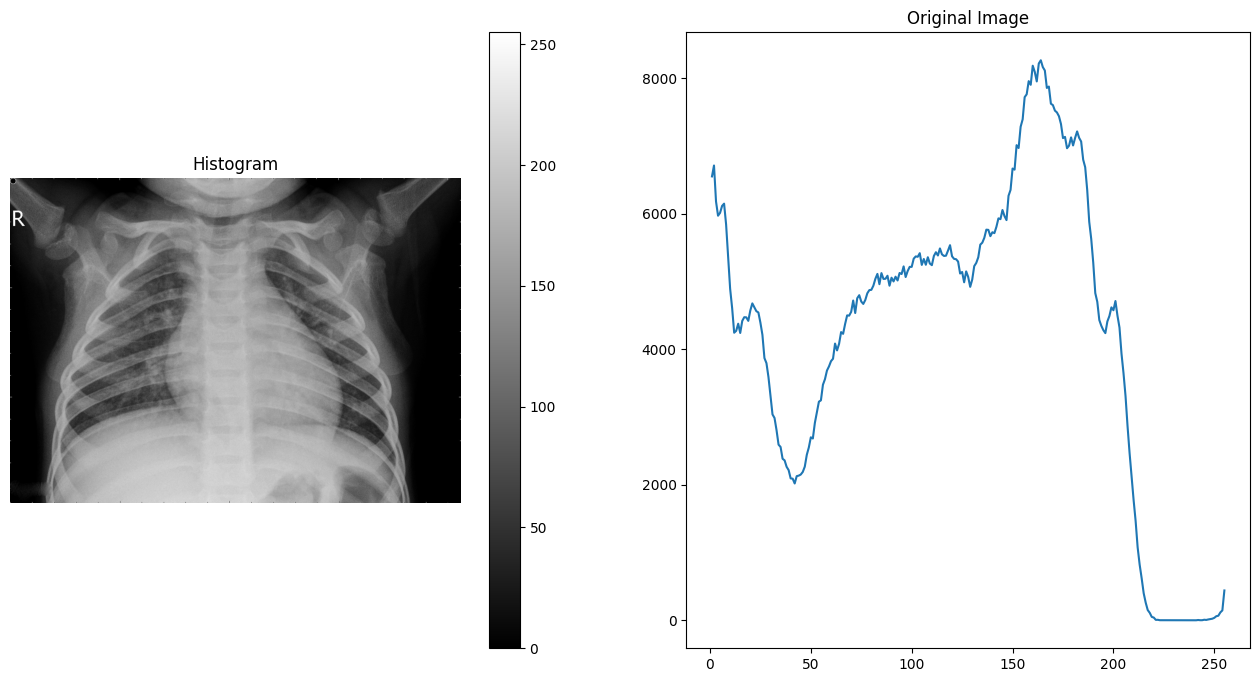

In [42]:
im = imageio.imread('../dataset/Assigment1/chest_xray/val/NORMAL/NORMAL2-IM-1436-0001.jpeg')
# im = imageio.imread('../dataset/Assigment1/chest_xray/val/NORMAL/NORMAL2-IM-1430-0001.jpeg')
# im = imageio.imread('../dataset/Assigment1/chest_xray/val/PNEUMONIA/person1949_bacteria_4880.jpeg')
# im = imageio.imread('../dataset/Assigment1/chest_xray/val/PNEUMONIA/person1950_bacteria_4881.jpeg')


print(im.shape, im.dtype)
hist = ndi.histogram(im, 0, 255, 256)
x = np.arange(1, len(hist))

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

im_display = ax[0].imshow(im, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Histogram')
ax[0].axis('off')

ax[1].plot(x, hist[1:])
ax[1].set_title('Original Image')

fig.colorbar(im_display, ax=ax[0])

plt.show()

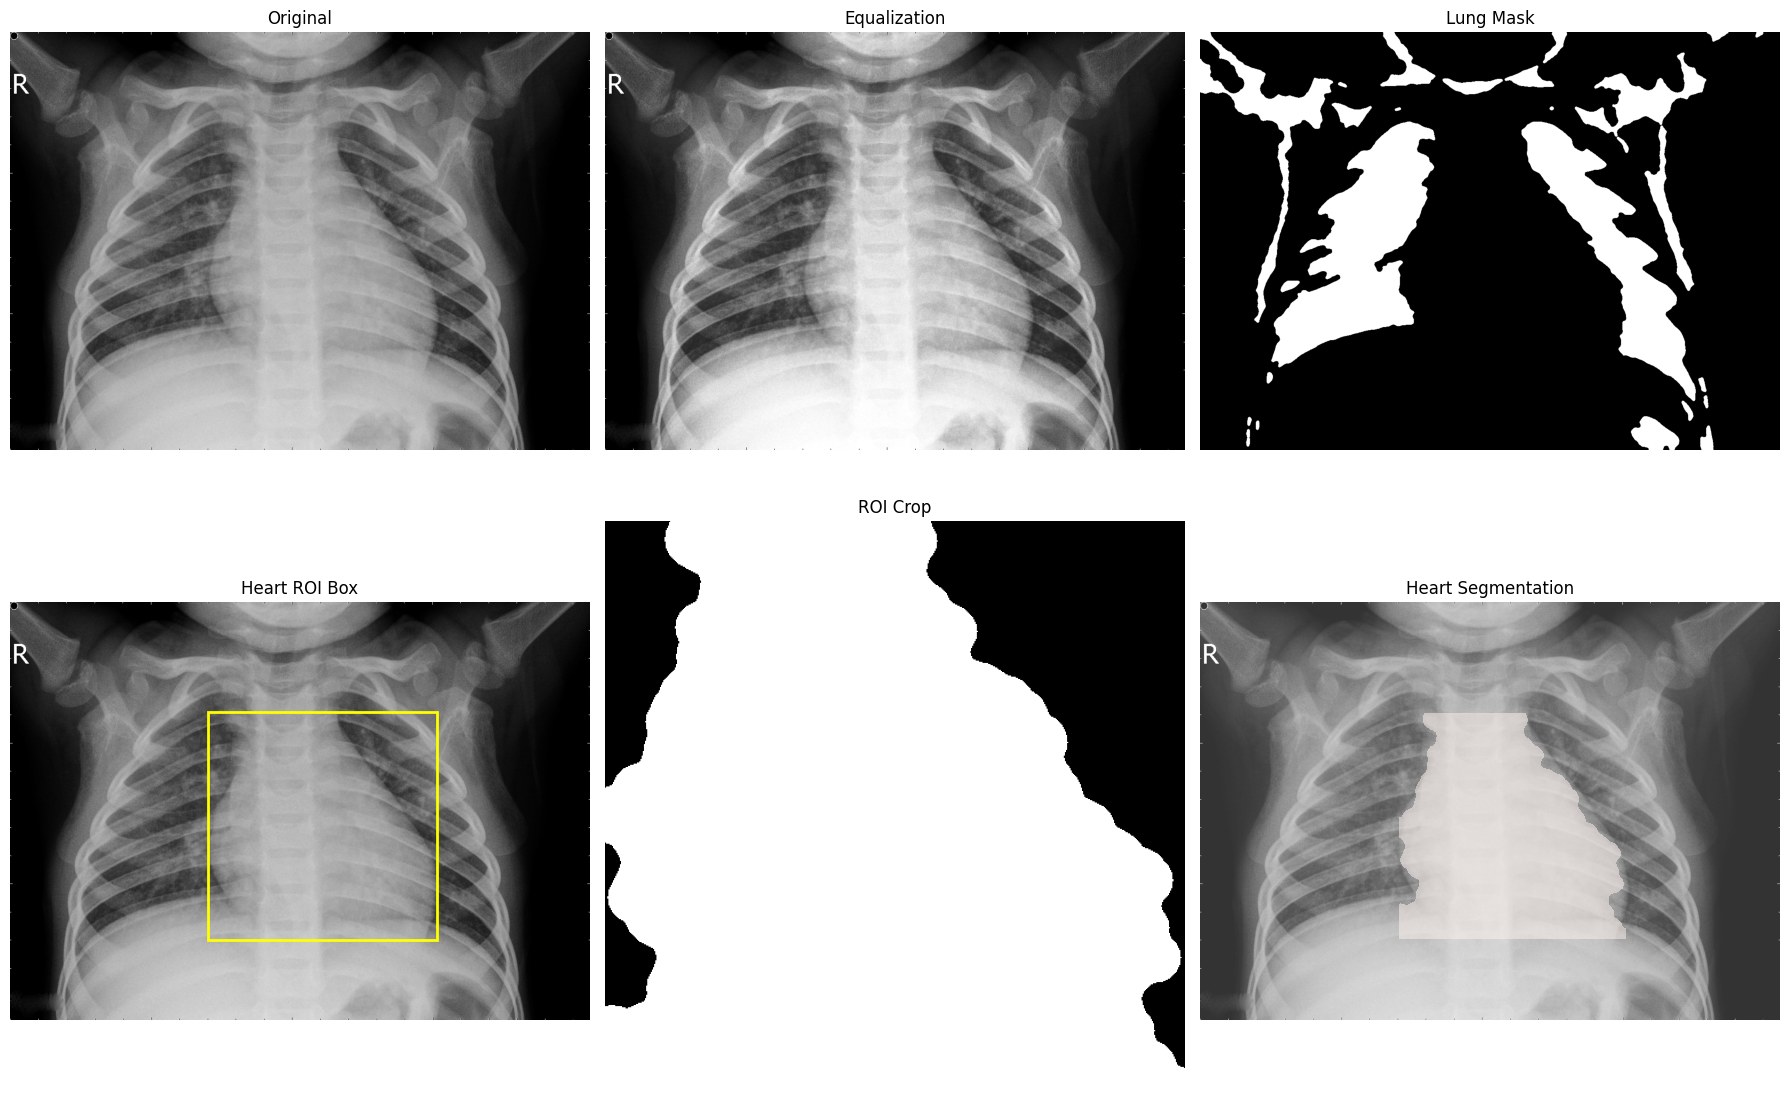

In [44]:
img_clahe = exposure.equalize_hist(im)
img_filt  = ndi.gaussian_filter(img_clahe, sigma=3)


th_body = filters.threshold_otsu(im)
body = im > th_body
body = morphology.binary_closing(body, morphology.disk(15))
body = ndi.binary_fill_holes(body)

th        = filters.threshold_otsu(img_filt)
lung_bin  = (img_filt < th) & body                                      # lungs = dark

lung_bin  = morphology.binary_closing(lung_bin, morphology.disk(5))
lung_bin  = ndi.binary_fill_holes(lung_bin)
lung_bin  = morphology.binary_opening(lung_bin, morphology.disk(3))

lung_mask = lung_bin.copy()

labeled = measure.label(lung_bin)
props = sorted(measure.regionprops(labeled), key=lambda r: r.area, reverse=True)

lung_props = sorted(props[:2], key=lambda r: r.centroid[1])   # sort left→right
L, R       = lung_props[0].bbox, lung_props[1].bbox
# (min_row, min_col, max_row, max_col)

roi_r0 = max(L[0], R[0])                    # top    of overlap zone
roi_r1 = min(L[2], R[2])                    # bottom of overlap zone
roi_c0 = L[3]                               # right edge of left lung
roi_c1 = R[1]                               # left  edge of right lung

h_pad  = int((roi_c1 - roi_c0) * 0.7)
v_pad  = int((roi_r1 - roi_r0) * 0.01) 
roi_r0 = max(0,          roi_r0 - v_pad) + 50
roi_r1 = min(im.shape[0], roi_r1 + v_pad) 
roi_c0 = max(0,          roi_c0 - h_pad) + 50
roi_c1 = min(im.shape[1], roi_c1 + h_pad) + 100

roi       = img_filt[roi_r0:roi_r1, roi_c0:roi_c1]

th_roi    = filters.threshold_otsu(roi)
heart_bin = roi > th_roi

heart_bin = morphology.binary_closing(heart_bin, morphology.disk(21))
heart_bin = ndi.binary_fill_holes(heart_bin)

heart_bin = morphology.binary_erosion(heart_bin, morphology.disk(8))
heart_bin = morphology.binary_dilation(heart_bin, morphology.disk(21))
heart_bin = ndi.binary_fill_holes(heart_bin)
hl        = measure.label(heart_bin)
hr        = sorted(measure.regionprops(hl), key=lambda r: r.area, reverse=True)
heart_roi = hl == hr[0].label

heart_full = np.zeros(im.shape, dtype=bool)
heart_full[roi_r0:roi_r1, roi_c0:roi_c1] = heart_roi

fig, ax = plt.subplots(2, 3, figsize=(18, 12))

ax[0,0].imshow(im,        cmap='gray'); ax[0,0].set_title('Original');        ax[0,0].axis('off')
ax[0,1].imshow(img_clahe, cmap='gray'); ax[0,1].set_title('Equalization');    ax[0,1].axis('off')
ax[0,2].imshow(lung_mask, cmap='gray'); ax[0,2].set_title('Lung Mask');       ax[0,2].axis('off')

ax[1,0].imshow(im, cmap='gray')
rect = mpatches.Rectangle((roi_c0, roi_r0), roi_c1-roi_c0, roi_r1-roi_r0,
                           lw=2, edgecolor='yellow', facecolor='none')
ax[1,0].add_patch(rect)
ax[1,0].set_title('Heart ROI Box'); ax[1,0].axis('off')

ax[1,1].imshow(heart_roi, cmap='gray');  ax[1,1].set_title('ROI Crop');            ax[1,1].axis('off')

ax[1,2].imshow(im,  cmap='gray', alpha=0.8)
ax[1,2].imshow(np.ma.masked_where(~heart_full, heart_full),
               cmap='Reds', alpha=0.5)
ax[1,2].set_title('Heart Segmentation'); ax[1,2].axis('off')

plt.tight_layout()
plt.show()

In [45]:
# ============================================================
# CARDIAC FEATURE EXTRACTION
# ============================================================
# Variabel yang harus sudah ada dari cell sebelumnya:
#   im          - gambar original (grayscale)
#   heart_full  - mask jantung pada gambar full (boolean)
#   lung_mask   - mask paru-paru (boolean)
#   L, R        - bbox paru kiri & kanan: (min_row, min_col, max_row, max_col)
#   roi_r0, roi_r1, roi_c0, roi_c1 - batas ROI jantung
#   labeled     - labeled lungs
#   lung_props  - regionprops paru-paru (sorted left→right)

from skimage.feature import graycomatrix, graycoprops
from scipy.ndimage import map_coordinates

thorax_left  = L[1]   
thorax_right = R[3]   
thorax_diameter = thorax_right - thorax_left

heart_rows = np.where(np.any(heart_full, axis=1))[0]
cardiac_widths = []
cardiac_details = []  # (row, left_col, right_col, width)

for r in heart_rows:
    cols = np.where(heart_full[r, :])[0]
    if len(cols) > 0:
        w = cols[-1] - cols[0]
        cardiac_widths.append(w)
        cardiac_details.append((r, cols[0], cols[-1], w))

cardiac_widths = np.array(cardiac_widths)
max_cardiac_idx = np.argmax(cardiac_widths)
cardiac_diameter = cardiac_widths[max_cardiac_idx]
cardiac_row, cardiac_left, cardiac_right, _ = cardiac_details[max_cardiac_idx]

CTR = cardiac_diameter / thorax_diameter

midline_col = (thorax_left + thorax_right) // 2
MR = cardiac_right - midline_col  
ML = midline_col - cardiac_left   
CTR_standard = (MR + ML) / thorax_diameter 

heart_label = measure.label(heart_full.astype(int))
heart_props = measure.regionprops(heart_label)

if heart_props:
    hp = heart_props[0]  
    
    heart_area = hp.area
    heart_perimeter = hp.perimeter
    heart_centroid = hp.centroid
    heart_bbox = hp.bbox
    heart_eccentricity = hp.eccentricity
    heart_major_axis = hp.major_axis_length
    heart_minor_axis = hp.minor_axis_length
    heart_orientation = hp.orientation
    heart_solidity = hp.solidity        
    heart_extent = hp.extent            
    
    circularity = (4 * np.pi * heart_area) / (heart_perimeter ** 2 + 1e-6)
    
    heart_height = heart_bbox[2] - heart_bbox[0]
    heart_width = heart_bbox[3] - heart_bbox[1]
    aspect_ratio = heart_width / (heart_height + 1e-6)
    
    equiv_diameter = hp.equivalent_diameter
    
heart_pixels = im[heart_full].astype(float)

heart_mean = np.mean(heart_pixels)
heart_std = np.std(heart_pixels)
heart_median = np.median(heart_pixels)
heart_min = np.min(heart_pixels)
heart_max = np.max(heart_pixels)
heart_skew = float(np.mean(((heart_pixels - heart_mean) / (heart_std + 1e-6)) ** 3))
heart_kurt = float(np.mean(((heart_pixels - heart_mean) / (heart_std + 1e-6)) ** 4))

lung_pixels = im[lung_mask].astype(float)
lung_mean = np.mean(lung_pixels)
heart_lung_ratio = heart_mean / (lung_mean + 1e-6)

hb = hp.bbox
heart_crop = im[hb[0]:hb[2], hb[1]:hb[3]].copy()
heart_mask_crop = heart_full[hb[0]:hb[2], hb[1]:hb[3]]
heart_crop[~heart_mask_crop] = 0

heart_q = (heart_crop // 16).astype(np.uint8)

glcm = graycomatrix(heart_q, 
                     distances=[1, 3, 5], 
                     angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                     levels=16, symmetric=True, normed=True)

contrast    = graycoprops(glcm, 'contrast').mean()
dissim      = graycoprops(glcm, 'dissimilarity').mean()
homogeneity = graycoprops(glcm, 'homogeneity').mean()
energy      = graycoprops(glcm, 'energy').mean()
correlation = graycoprops(glcm, 'correlation').mean()

heart_center_r, heart_center_c = heart_centroid
thorax_center_c = midline_col
thorax_top = min(L[0], R[0])
thorax_bottom = max(L[2], R[2])
thorax_height = thorax_bottom - thorax_top

midline_displacement = thorax_center_c - heart_center_c
midline_displacement_norm = midline_displacement / (thorax_diameter / 2)

vertical_position = (heart_center_r - thorax_top) / thorax_height

thorax_area = np.sum(lung_mask) + heart_area  
heart_thorax_area_ratio = heart_area / (thorax_area + 1e-6)


In [ ]:
import pandas as pd

data = {
    # --- Geometry (pixel) ---
    "Thorax_Diameter(px)": thorax_diameter,
    "Cardiac_Diameter(px)": cardiac_diameter,
    "MR(px)": MR,
    "ML(px)": ML,

    # --- Ratios (unitless) ---
    "CTR": CTR,
    "CTR_Standard": CTR_standard,

    # --- Heart properties ---
    "Heart_Area(px)2": heart_area,
    "Heart_Perimeter(px)": heart_perimeter,
    "Heart_Major_Axis(px)": heart_major_axis,
    "Heart_Minor_Axis(px)": heart_minor_axis,
    "Heart_Height(px)": heart_height,
    "Heart_Width(px)": heart_width,
    "Equivalent_Diameter(px)": equiv_diameter,

    # --- Shape (unitless) ---
    "Eccentricity": heart_eccentricity,
    "Solidity": heart_solidity,
    "Extent": heart_extent,
    "Aspect_Ratio": aspect_ratio,
    "Circularity": circularity,

    # --- Intensity ---
    "Heart_Mean_intensity": heart_mean,
    "Heart_STD_intensity": heart_std,
    "Heart_Median_intensity": heart_median,
    "Heart_Min_intensity": heart_min,
    "Heart_Max_intensity": heart_max,
    "Heart_Skewness": heart_skew,
    "Heart_Kurtosis": heart_kurt,

    # --- Lung comparison ---
    "Lung_Mean_intensity": lung_mean,
    "Heart_Lung_Ratio": heart_lung_ratio,

    # --- Texture ---
    "GLCM_Contrast": contrast,
    "GLCM_Dissimilarity": dissim,
    "GLCM_Homogeneity": homogeneity,
    "GLCM_Energy": energy,
    "GLCM_Correlation": correlation,

    # --- Spatial ---
    "Midline_Displacement(px)": midline_displacement,
    "Midline_Displacement_norm": midline_displacement_norm,
    "Vertical_Position_norm": vertical_position,

    # --- Area ---
    "Thorax_Area(px)2": thorax_area,
    "Heart_Thorax_Area_Ratio": heart_thorax_area_ratio,
}

df = pd.DataFrame([data])
df

,Thorax_Diameter_px,Cardiac_Diameter_px,MR_px,ML_px,CTR,CTR_Standard,Heart_Area_px2,Heart_Perimeter_px,Heart_Major_Axis_px,Heart_Minor_Axis_px,...,GLCM_Contrast,GLCM_Dissimilarity,GLCM_Homogeneity,GLCM_Energy,GLCM_Correlation,Midline_Displacement_px,Midline_Displacement_norm,Vertical_Position_norm,Thorax_Area_px2,Heart_Thorax_Area_Ratio
0,943,506,317,189,0.536585,0.536585,196391.0,2078.236724,577.636473,467.195407,...,0.677008,0.284529,0.880878,0.37141,0.981514,-41.526226,-0.088073,0.536897,430086.0,0.456632
